In [42]:
import pandas as pd
import asyncio
import asyncpg
import pandas as pd
import os
from dotenv import load_dotenv
import seaborn as sns

load_dotenv('/home/ubuntu/ai-stocks/.env')

DATABASE_URL = os.getenv("DATABASE_URL")

async def fetch():
    pool = await asyncpg.create_pool(DATABASE_URL)
    async with pool.acquire() as conn:
        rows = await conn.fetch("SELECT * FROM cleaned_data_ai_stocks")
    await pool.close()
    return pd.DataFrame([dict(r) for r in rows])

df = await fetch()

In [43]:
df["date"] = pd.to_datetime(df["date"])
df = df[df["is_relevant"]==1]
df.reset_index(drop=True, inplace=True)
df.drop(columns=["id"], inplace=True)

In [66]:
df

,date,time,url,subreddit,content_type,author_handle,title,body,upvotes,comment_count,full_text,relevance_score,is_relevant,sentiment,is_financial_sector
0,2026-04-24,17:21:28,https://www.reddit.com/r/stocks/comments/1sulm...,r/stocks,forum_reply,TranslatorRoyal1016,,"calls on nvda, puts on intc",4,NaN,"calls on nvda, puts on intc",18.721794,1,bullish,0
1,2024-02-24,07:30:58,https://www.reddit.com/r/investing/comments/1a...,r/investing,forum_reply,MinuetInUrsaMajor,,&amp;gt; High risk of shift from LLM training ...,11,NaN,&amp;gt; High risk of shift from LLM training...,17.042927,1,bearish,0
2,2026-05-22,14:28:48,https://www.reddit.com/r/BingX/comments/1tkgus...,r/BingX,forum_reply,Maxymalyst,,The analysis is great; artificial intelligence...,1,NaN,The analysis is great; artificial intelligenc...,16.704000,1,bullish,0
3,2025-11-19,21:41:44,https://www.reddit.com/r/ValueInvesting/commen...,r/ValueInvesting,forum_reply,MarketFlux,,AND the stock market survives another day lol ...,2,NaN,AND the stock market survives another day lol...,16.264044,1,bullish,0
4,2025-08-09,12:46:39,https://www.reddit.com/r/wallstreetbets/commen...,r/wallstreetbets,forum_reply,PMG_MOON,,Why puts calls earnings for nvda in 2 weeks 20...,1,NaN,Why puts calls earnings for nvda in 2 weeks 2...,16.151594,1,bullish,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3661,2025-11-30,11:26:51,https://www.reddit.com/r/ValueInvesting/commen...,r/ValueInvesting,forum_reply,Ma4r,,Depreciation cycle isn't based on the value th...,9,NaN,Depreciation cycle isn't based on the value t...,1.384764,1,bearish,0
3662,2025-11-30,11:11:54,https://www.reddit.com/r/ValueInvesting/commen...,r/ValueInvesting,forum_reply,Ma4r,,Depreciation cycle isn't based on the value th...,2,NaN,Depreciation cycle isn't based on the value t...,1.381916,1,bearish,0
3663,2026-05-09,13:40:28,https://www.reddit.com/r/wallstreetbets/commen...,r/wallstreetbets,forum_reply,Constant_Tomorrow_69,,Akamai doesn’t need AI to get companies hooked...,4,NaN,Akamai doesn’t need AI to get companies hooke...,1.308588,1,bullish,0
3664,2025-11-27,16:34:32,https://www.reddit.com/r/stocks/comments/1p7ye...,r/stocks,forum_reply,virtual_adam,,Reading too deep into 5 year plans means nothi...,2,NaN,Reading too deep into 5 year plans means noth...,1.286242,1,bullish,0


**Platform Activity Statistics**

In [45]:
author_list = df["author_handle"].to_list()
df_posts_only = df[df["content_type"] == "forum_post"]
df_reply_only = df[df["content_type"] == "forum_reply"]

post_authors = set(df_posts_only["author_handle"].unique())
reply_authors = set(df_reply_only["author_handle"].unique())

posts_only = post_authors - reply_authors
Comments_only = reply_authors - post_authors
both = post_authors & reply_authors

df_activity = pd.DataFrame({
    "Category": ["Post only", "Reply only", "Both"],
    "Count": [len(posts_only), len(Comments_only), len(both)],
    "Proportion": [len(posts_only)/(len(author_list)), len(Comments_only)/(len(author_list)), len(both)/(len(author_list))]
})
df_activity

,Category,Count,Proportion
0,Post only,77,0.021004
1,Reply only,2394,0.653028
2,Both,74,0.020185


**Posts and Comments Frequency**

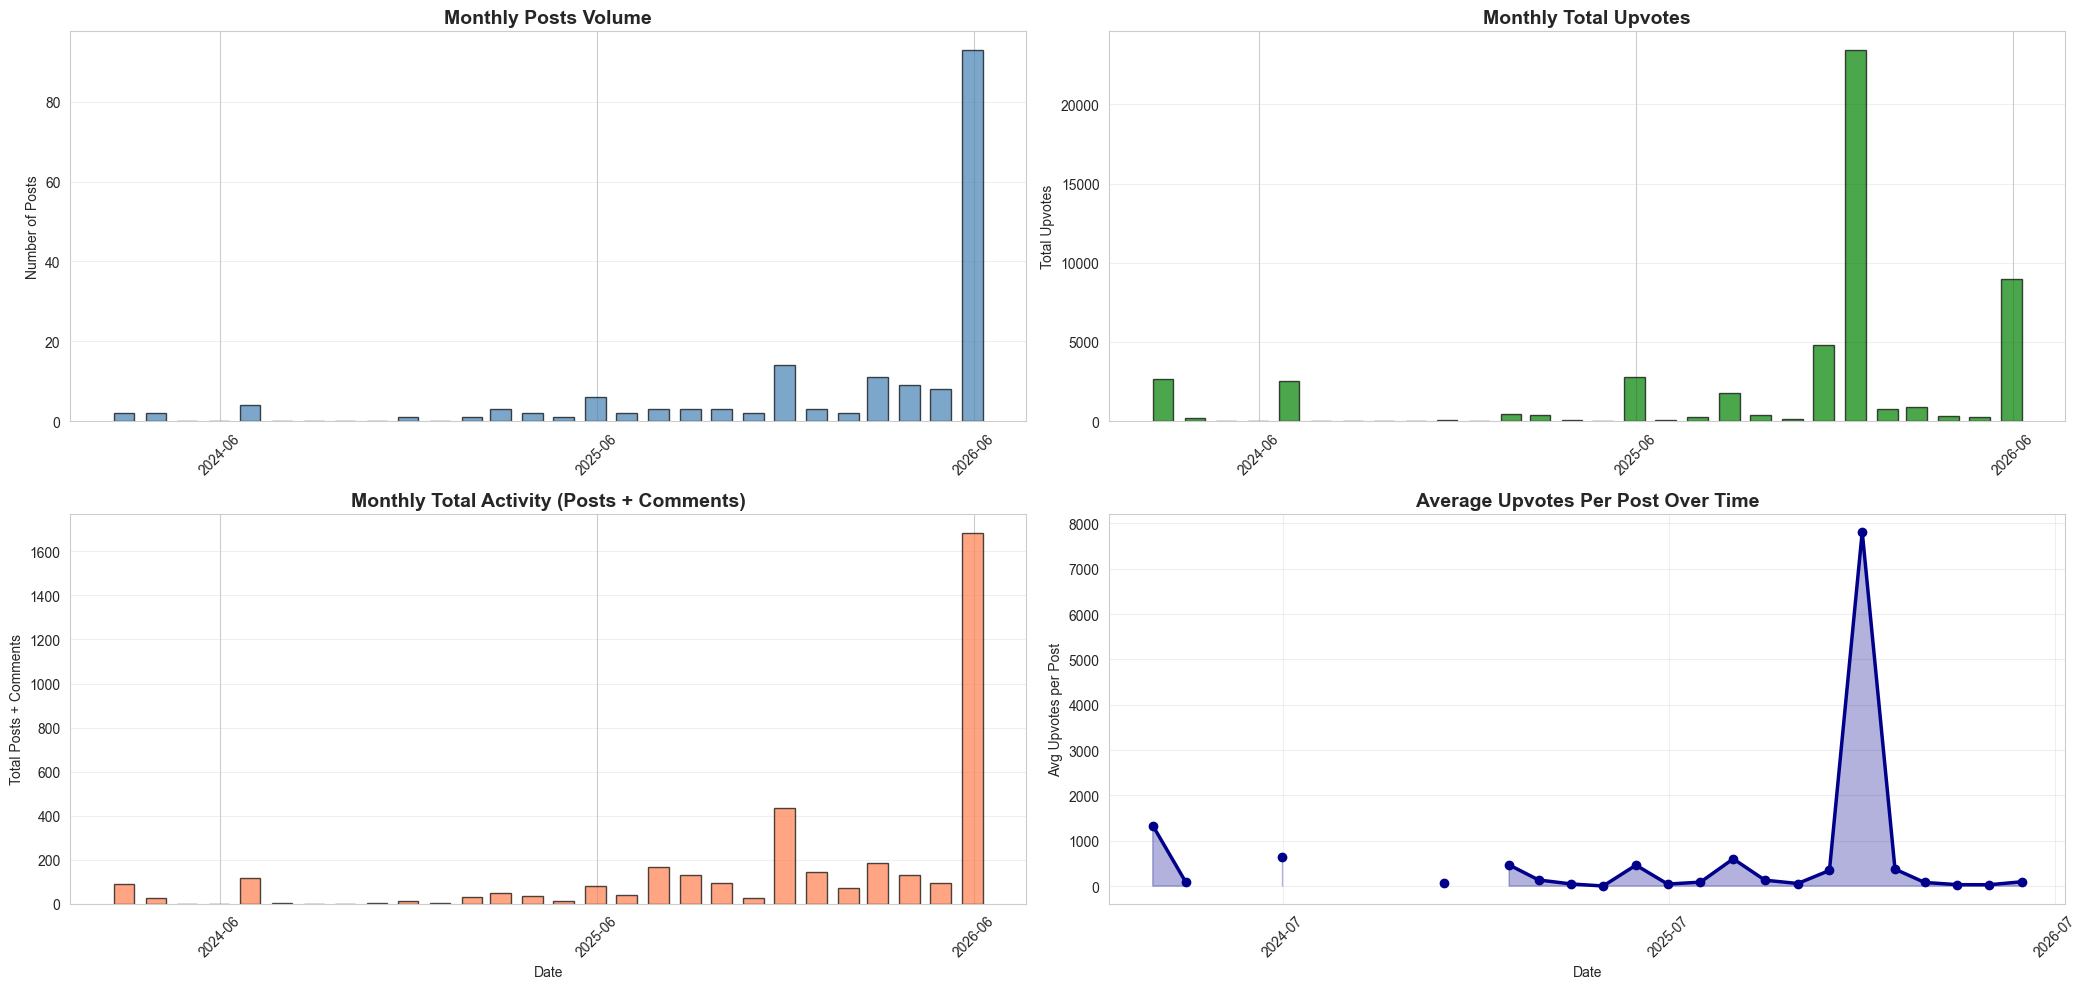

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

df_frequency = df.copy()

# Split by content type
df_posts    = df_frequency[df_frequency["content_type"] == "forum_post"]
df_comments = df_frequency[df_frequency["content_type"] == "forum_reply"]

monthly_posts  = df_posts.set_index("date").resample("ME").size().reset_index(name="Post Count")
monthly_total  = df_frequency.set_index('date').resample('ME').size().reset_index(name='total_activity')
monthly_upvotes = df_posts.groupby(pd.Grouper(key='date', freq='ME'))['upvotes'].sum().reset_index()
monthly_avg_upvotes = df_posts.groupby(pd.Grouper(key='date', freq='ME')).agg(
    avg_upvotes_per_post=('upvotes', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(21, 10))

# GRAPH 1: Monthly Posts
axes[0, 0].bar(monthly_posts['date'], monthly_posts['Post Count'],
               width=20, edgecolor='black', color='steelblue', alpha=0.7)
axes[0, 0].set_title('Monthly Posts Volume', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Number of Posts')
axes[0, 0].grid(axis='y', alpha=0.3)
axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0, 0].tick_params(axis='x', rotation=45)

# GRAPH 2: Monthly Upvotes
axes[0, 1].bar(monthly_upvotes['date'], monthly_upvotes['upvotes'],
               width=20, edgecolor='black', color='green', alpha=0.7)
axes[0, 1].set_title('Monthly Total Upvotes', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Total Upvotes')
axes[0, 1].grid(axis='y', alpha=0.3)
axes[0, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[0, 1].tick_params(axis='x', rotation=45)

# GRAPH 3: Monthly Total Activity (Posts + Comments)
axes[1, 0].bar(monthly_total['date'], monthly_total['total_activity'],
               width=20, edgecolor='black', color='coral', alpha=0.7)
axes[1, 0].set_title('Monthly Total Activity (Posts + Comments)',
                     fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Date')
axes[1, 0].set_ylabel('Total Posts + Comments')
axes[1, 0].grid(axis='y', alpha=0.3)
axes[1, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1, 0].tick_params(axis='x', rotation=45)

# GRAPH 4: Average Upvotes Per Post
axes[1, 1].plot(monthly_avg_upvotes['date'], monthly_avg_upvotes['avg_upvotes_per_post'],
                color='darkblue', linewidth=2.5, marker='o', markersize=6)
axes[1, 1].fill_between(monthly_avg_upvotes['date'], 0, monthly_avg_upvotes['avg_upvotes_per_post'],
                        alpha=0.3, color='darkblue')
axes[1, 1].set_title('Average Upvotes Per Post Over Time',
                     fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Date')
axes[1, 1].set_ylabel('Avg Upvotes per Post')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=12))
axes[1, 1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Earlier dates have inconsistent data coverage, so we filter from 2025-05 onwards for a cleaner analysis.

In [64]:
# Filter from 2025-06 onwards for consistent data
df_frequency = df[df['date'] >= '2025-05-01'].copy()

# Split by content type
df_posts    = df_frequency[df_frequency["content_type"] == "forum_post"]
df_comments = df_frequency[df_frequency["content_type"] == "forum_reply"]

In [65]:
df_frequency["sentiment"].value_counts(normalize=True)

sentiment
bullish    0.457457
neutral    0.252516
bearish    0.229948
mixed      0.060079
Name: proportion, dtype: float64

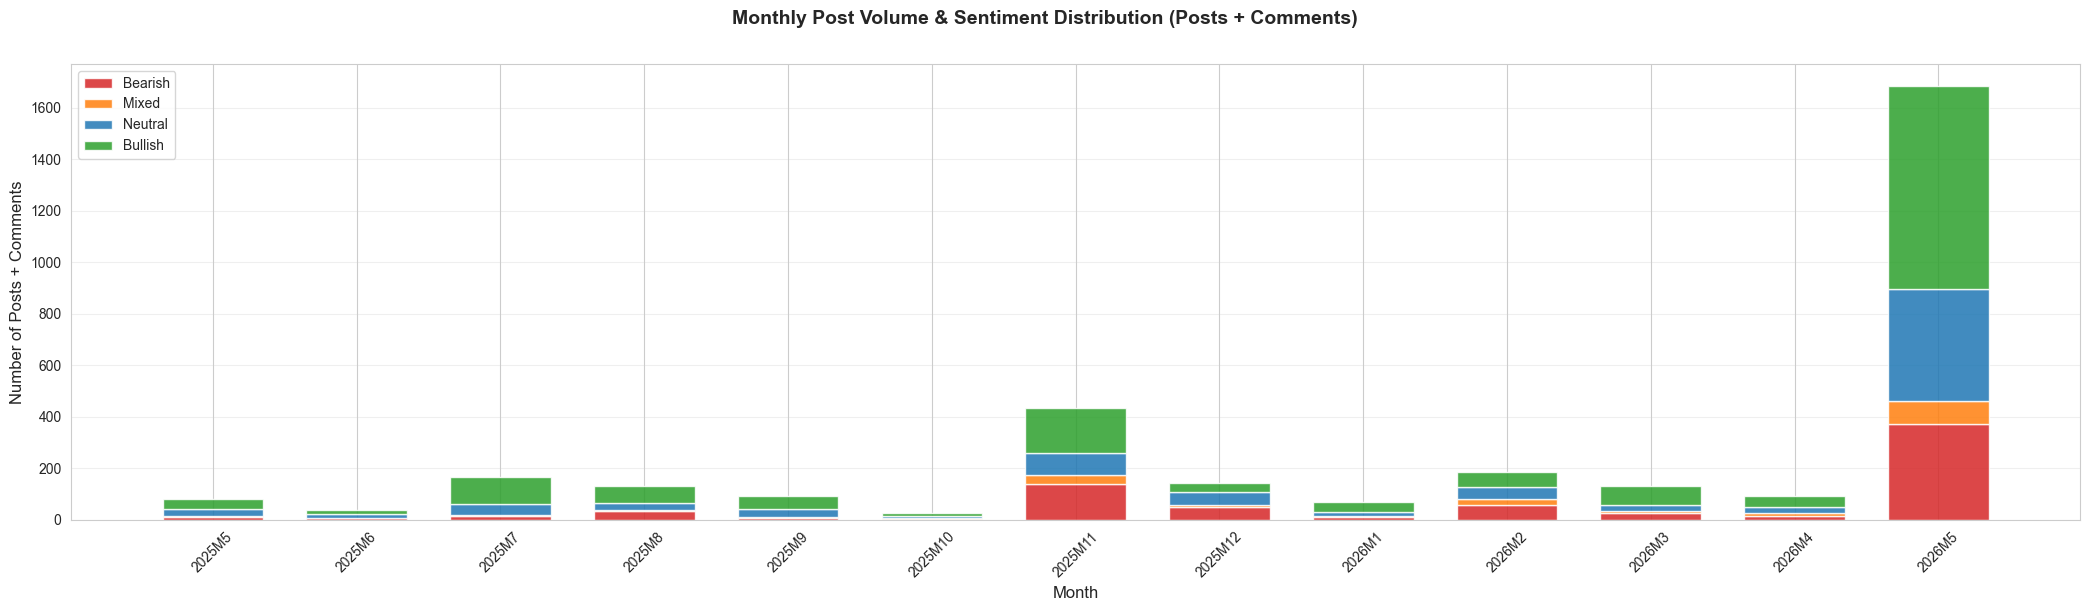

In [67]:
quarterly_stats = (
    df_frequency
    .set_index("date")
    .resample("ME")
    .agg(
        post_count=('sentiment', 'count'),
        pct_bearish=('sentiment', lambda x: (x == 'bearish').mean()),
        pct_mixed=('sentiment', lambda x: (x == 'mixed').mean()),
        pct_neutral=('sentiment', lambda x: (x == 'neutral').mean()),
        pct_bullish=('sentiment', lambda x: (x == 'bullish').mean())
    )
    .reset_index()
)

quarterly_stats["period_str"] = quarterly_stats["date"].dt.year.astype(str) + "M" + quarterly_stats["date"].dt.month.astype(str)

sns.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(21, 6))

x = range(len(quarterly_stats))
width = 0.7

bearish_counts = quarterly_stats['pct_bearish'] * quarterly_stats['post_count']
mix_counts     = quarterly_stats['pct_mixed']   * quarterly_stats['post_count']
neu_counts     = quarterly_stats['pct_neutral']  * quarterly_stats['post_count']
bullish_counts = quarterly_stats['pct_bullish'] * quarterly_stats['post_count']

ax.bar(x, bearish_counts, width, label='Bearish', color='#d62728', alpha=0.85)
ax.bar(x, mix_counts,     width, bottom=bearish_counts,
       label='Mixed', color='#ff7f0e', alpha=0.85)
ax.bar(x, neu_counts,     width, bottom=bearish_counts + mix_counts,
       label='Neutral', color='#1f77b4', alpha=0.85)
ax.bar(x, bullish_counts, width, bottom=bearish_counts + mix_counts + neu_counts,
       label='Bullish', color='#2ca02c', alpha=0.85)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Posts + Comments', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(quarterly_stats['period_str'], rotation=45)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Monthly Post Volume & Sentiment Distribution (Posts + Comments)',
             fontsize=14, fontweight='bold', y=1.01)

plt.tight_layout()
plt.show()

In [68]:
sentiment_counts = df_frequency["sentiment"].value_counts()

labels = sentiment_counts.index
values = sentiment_counts.values

import plotly.express as px

fig = px.pie(
    values=values,
    names=labels,
    title="Overall Sentiment Distribution"
)

fig.show()

In [72]:
from IPython.display import HTML, display

# Define sentiment colors
sentiment_info = {
    'bearish': {'color': '#d62728', 'name': 'Bearish'},
    'neutral': {'color': '#1f77b4', 'name': 'Neutral'},
    'bullish': {'color': '#2ca02c', 'name': 'Bullish'},
    'mixed':   {'color': '#ff7f0e', 'name': 'Mixed'}
}

html = """
<div style='max-height: 600px; overflow-y: auto; border: 2px solid #333; padding: 10px; border-radius: 8px;'>
    <h2 style='position: sticky; top: 0; background: white; margin: 0; padding: 10px 0; z-index: 10;'>
        Sample Posts by Sentiment (Posts Only)
    </h2>
"""

for sentiment, info in sentiment_info.items():
    sentiment_posts = df_frequency[df_frequency['sentiment'] == sentiment]
    
    # Get top 3 most upvoted posts for this sentiment
    top_posts = sentiment_posts.nlargest(3, 'upvotes')
    
    html += f"""
    <div style='margin: 20px 0; padding: 15px; background: #f5f5f5; border-radius: 8px; border-left: 5px solid {info['color']};'>
        <h3 style='margin-top: 0; color: {info['color']};'>
            {info['name']} Sentiment
        </h3>
        <p style='margin: 5px 0; font-size: 13px; color: #666;'>
            <strong>Posts with this sentiment:</strong> {len(sentiment_posts)} ({len(sentiment_posts)/len(df_frequency)*100:.1f}%)
        </p>
    """
    
    for i, (idx, row) in enumerate(top_posts.iterrows(), 1):
        html += f"""
        <div style='margin: 10px 0; padding: 12px; background: white; border-radius: 5px; border: 1px solid #ddd;'>
            <div style='margin-bottom: 8px;'>
                <span style='font-size: 12px; color: #666;'>
                    <strong>Example {i}</strong> | 
                    Date: {row['date']} | 
                    {row['upvotes']} 👍 | 
                    {row['comment_count']} 💬
                </span>
            </div>
            <details>
                <summary style='cursor: pointer; font-weight: bold; color: #555; font-size: 13px;'>
                    Click to expand
                </summary>
                <p style='white-space: pre-wrap; line-height: 1.6; margin: 10px 0 0 0; font-family: Arial, sans-serif; font-size: 13px;'>
                    {row['full_text']}
                </p>
                <p style='margin: 5px 0 0 0;'>
                    <a href='{row['url']}' target='_blank' style='color: #1a73e8; text-decoration: none; font-size: 12px;'>
                        View on Reddit →
                    </a>
                </p>
            </details>
        </div>
        """
    
    html += "</div>"

html += "</div>"

display(HTML(html))